### Directional Splitting



In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def vorticity(x,y,t,nu):
    decay = np.exp(-2*nu*t)
    return 2*np.sin(x)*np.sin(y)*decay

In [13]:
def velocity(x, y, t, nu):
    decay = np.exp(-2 * nu * t)

    u = np.sin(x) * np.cos(y) * decay
    v = -np.cos(x) * np.sin(y) * decay

    return u + 1j * v

In [26]:
def m4prime_1d(s):
    """
    Monaghan's M4' remeshing kernel (paper Eq. 53-54):

        W(s) = 1 - 5/2 |s|^2 + 3/2 |s|^3            for |s| <= 1
        W(s) = 1/2 (1-|s|)(2-|s|)^2                  for 1 <= |s| <= 2
        W(s) = 0                                      otherwise

    Piecewise cubic, C^1, support [-2, 2], order p=2 (conserves circulation,
    linear impulse and angular impulse).
    """
    s = np.abs(np.asarray(s, dtype=float))
    w = np.zeros_like(s)

    m1 = s <= 1.0
    m2 = (s > 1.0) & (s <= 2.0)
    m3 = (s > 2.0) & (s <= 3.0)

    #w[m1] = 1 - 5/2 * s[m1] ** 2 + 3/2 * s[m1] ** 3
    #w[m2] = 1/2 * (1 - s[m2]) * ((2 - s[m2]) ** 2)
    w[m1] = 1.0 - 1 * s[m1] ** 2 - 4.5 * s[m1] ** 3 + 7.5 * s[m1] ** 4 - 3 * s[m1] ** 5
    w[m2] = -4 + 18 * s[m2] ** 1  - 29 * s[m2] ** 2 + (43/2) * s[m2] ** 3 -  7.5 * s[m2] ** 4 + 1 * s[m2] ** 5

    #w[m1] = 1.0 - (5/4) * s[m1] ** 2 - (35/12) * s[m1] ** 3 + (21/4) * s[m1] ** 4 - (25/12) * s[m1] ** 5
    #w[m2] = -4 + (75/4) * s[m2] ** 1  - (245/8) * s[m2] ** 2 + (545/24) * s[m2] ** 3 -  (63/8) * s[m2] ** 4 + (25/24) * s[m2] ** 5
    #w[m3] = 18 - (153/4) * s[m3] ** 1  + (255/8) * s[m3] ** 2 - (313/24) * s[m3] ** 3 +  (21/8) * s[m3] ** 4 - (5/24) * s[m3] ** 5
    return w

In [44]:
def m4prime_1d(s):

    s = np.abs(np.asarray(s, dtype=float))
    w = np.zeros_like(s)

    m1 = s <= 1.0
    m2 = (s > 1.0) & (s <= 2.0)

    w[m1] = (
        1
        - 2.5 * s[m1]**2
        + 1.5 * s[m1]**3
    )

    w[m2] = (
        0.5
        * (1 - s[m2])
        * (2 - s[m2])**2
    )

    return w

In [56]:
"""def p2m(particles, mesh, h):

    Nx, Ny = mesh.shape
    mesh.fill(0.0)

    for p in particles:
        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        # Base index of the cell the particle sits in
        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        # M4' has support [-2h, 2h], so stencil spans i0-1 to i0+2 (4 nodes)
        for di in range(-1, 3):
            for dj in range(-1, 3):
                ig = (i0 + di) % Nx
                jg = (j0 + dj) % Ny

                # Normalised distances in x and y separately
                sx = (xp - (i0 + di) * h) / h
                sy = (yp - (j0 + dj) * h) / h

                # 2D kernel is tensor product of two 1D kernels
                w = m4prime_1d(sx) * m4prime_1d(sy)

                mesh[ig, jg] += w * p["a"] / h**2

    return mesh
"""

def p2m(particles, mesh, h, L, B):

    Nx, Ny = mesh.shape
    n = 2
    mesh.fill(0.0)

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        wx = np.zeros(2 * n)
        wy = np.zeros(2 * n)

        ix = np.zeros(2 * n, dtype=int)
        iy = np.zeros(2 * n, dtype=int)

        # -------------------------
        # X direction
        # -------------------------

        for k, di in enumerate(range(-n + 1, n + 1)):

            ig = (i0 + di) % Nx

            dx = xp - (i0 + di) * h

            # periodic distance
            dx -= L * np.round(dx / L)

            sx = dx / h

            wx[k] = m4prime_1d(np.array([sx]))[0]
            ix[k] = ig

        # -------------------------
        # Y direction
        # -------------------------

        for k, dj in enumerate(range(-n + 1, n + 1)):

            jg = (j0 + dj) % Ny

            dy = yp - (j0 + dj) * h

            # periodic distance
            dy -= B * np.round(dy / B)

            sy = dy / h

            wy[k] = m4prime_1d(np.array([sy]))[0]
            iy[k] = jg

        # particle vorticity contribution
        ap = p["a"] / h**2


        c = np.outer(wx, wy)

        ix = (i0 + np.arange(-n + 1, n + 1)) % Nx
        iy = (j0 + np.arange(-n + 1, n + 1)) % Ny

        mesh[np.ix_(ix, iy)] += c * ap


        """# tensor-product kernel
        for k in range(4):

            for l in range(4):

                mesh[ix[k], iy[l]] += (
                    wx[k] * wy[l] * ap
                )
                    """
    return mesh

"""def p2m(particles, mesh, h):

    Nx, Ny = mesh.shape
    mesh.fill(0.0)

    for p in particles:
        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        wx = [0.0, 0.0, 0.0, 0.0]
        ix = [0, 0, 0, 0]

        for k, di in enumerate(range(-1, 3)):
            ig = (i0 + di) % Nx
            sx = (xp - (i0 + di) * h) / h
            wx[k] = m4prime_1d(np.atleast_1d(sx))[0]
            ix[k] = ig

        wy = [0.0, 0.0, 0.0, 0.0]
        iy = [0, 0, 0, 0]

        for k, dj in enumerate(range(-1, 3)):
            jg = (j0 + dj) % Ny
            sy = (yp - (j0 + dj) * h) / h
            wy[k] = m4prime_1d(np.atleast_1d(sy))[0]
            iy[k] = jg

        ap = p["a"] / h**2

        for k in range(4):
            ig = ix[k]
            wxk = wx[k] * ap
            for l in range(4):
                jg = iy[l]
                mesh[ig, jg] += wxk * wy[l]

    return mesh"""

'def p2m(particles, mesh, h):\n\n    Nx, Ny = mesh.shape\n    mesh.fill(0.0)\n\n    for p in particles:\n        xp = np.real(p["pos"])\n        yp = np.imag(p["pos"])\n\n        i0 = int(np.floor(xp / h))\n        j0 = int(np.floor(yp / h))\n\n        wx = [0.0, 0.0, 0.0, 0.0]\n        ix = [0, 0, 0, 0]\n\n        for k, di in enumerate(range(-1, 3)):\n            ig = (i0 + di) % Nx\n            sx = (xp - (i0 + di) * h) / h\n            wx[k] = m4prime_1d(np.atleast_1d(sx))[0]\n            ix[k] = ig\n\n        wy = [0.0, 0.0, 0.0, 0.0]\n        iy = [0, 0, 0, 0]\n\n        for k, dj in enumerate(range(-1, 3)):\n            jg = (j0 + dj) % Ny\n            sy = (yp - (j0 + dj) * h) / h\n            wy[k] = m4prime_1d(np.atleast_1d(sy))[0]\n            iy[k] = jg\n\n        ap = p["a"] / h**2\n\n        for k in range(4):\n            ig = ix[k]\n            wxk = wx[k] * ap\n            for l in range(4):\n                jg = iy[l]\n                mesh[ig, jg] += wxk * wy[l]\n\n  

In [107]:
def poisson_solver(omega, h):

    Nx, Ny = omega.shape

    dx, dy = h, h

    kx=2*np.pi*np.fft.fftfreq(Nx,d=dx)
    ky=2*np.pi*np.fft.fftfreq(Ny,d=dy)

    KX,KY = np.meshgrid(kx,ky,indexing="ij")
    K2 = KX ** 2 + KY ** 2

    K2[0,0]=1.0

    omega_hat=np.fft.fft2(omega)

    psi_hat=-omega_hat/K2
    psi_hat[0,0]=0.0

    psi=np.real(np.fft.ifft2(psi_hat))

    u_hat=1j*KY*psi_hat
    v_hat=-1j*KX*psi_hat

    u=np.real(np.fft.ifft2(u_hat))
    v=np.real(np.fft.ifft2(v_hat))

    U = u + 1j * v

    return U

In [4]:
"""def m2p(particles, mesh, h, type):

    Nx, Ny = mesh.shape

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        # -----------------------------------------------------
        # Base grid indices
        # -----------------------------------------------------

        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        # -----------------------------------------------------
        # Accumulated interpolated value
        # -----------------------------------------------------

        value = 0.0

        # -----------------------------------------------------
        # M4' has support [-2h, 2h]
        # Therefore 4 x 4 = 16 grid points
        # -----------------------------------------------------

        for di in range(-1, 3):

            ig = (i0 + di) % Nx

            # Physical x-coordinate of grid node
            xg = (i0 + di) * h

            # Normalized x-distance
            sx = (xp - xg) / h

            wx = m4prime_1d(sx)

            for dj in range(-1, 3):

                jg = (j0 + dj) % Ny

                # Physical y-coordinate of grid node
                yg = (j0 + dj) * h

                # Normalized y-distance
                sy = (yp - yg) / h

                wy = m4prime_1d(sy)

                # Tensor-product kernel
                w = wx * wy

                # Mesh -> particle contribution
                value += mesh[ig, jg] * w

        # -----------------------------------------------------
        # Store result
        # -----------------------------------------------------

        if type == 'v':

            p["u"] = value

        elif type == 'w':

            # mesh contains vorticity
            # particle stores circulation
            p["a"] = value * h**2

        else:

            raise ValueError(
                "type must be 'v' or 'w'"
            )

    return particles

"""

def m2p(particles, mesh, h, type):

    Nx, Ny = mesh.shape

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        wx = [0.0, 0.0, 0.0, 0.0]
        ix = [0, 0, 0, 0]

        for k, di in enumerate(range(-1, 3)):
            ig = (i0 + di) % Nx
            xg = (i0 + di) * h
            sx = (xp - xg) / h
            wx[k] = m4prime_1d(np.atleast_1d(sx))[0]
            ix[k] = ig

        wy = [0.0, 0.0, 0.0, 0.0]
        iy = [0, 0, 0, 0]

        for k, dj in enumerate(range(-1, 3)):
            jg = (j0 + dj) % Ny
            yg = (j0 + dj) * h
            sy = (yp - yg) / h
            wy[k] = m4prime_1d(np.atleast_1d(sy))[0]
            iy[k] = jg

        value = 0.0

        for k in range(4):
            ig = ix[k]
            wxk = wx[k]
            for l in range(4):
                jg = iy[l]
                value += mesh[ig, jg] * wxk * wy[l]

        if type == 'v':
            p["u"] = value
        elif type == 'w':
            p["a"] = value * h**2
        else:
            raise ValueError("type must be 'v' or 'w'")

    return particles

In [ ]:
def advect(particles, dt, Lx, Ly, dirn, dimn):

    if dimn == 1:
        for p in particles:

            if dirn == 0:
                p["pos"] += np.real(p["u"]) * dt

                x = np.real(p["pos"]) % Lx
                y = np.imag(p["pos"]) % Ly

                u = np.imag(p["u"]) * 1j

            elif dirn == 1:
                p["pos"] += p["u"] * dt

                x = np.real(p["pos"]) % Lx
                y = np.imag(p["pos"]) % Ly

                u = 0

            p["pos"] = x + 1j*y
            p['u'] = u

    elif dimn == 2:

        for p in particles:
            p['pos'] += p['u'] * dt
            p['u'] == 0
            
    return particles

In [6]:
def p2m2(particles, mesh, h):

    Nx, Ny = mesh.shape
    gamma_grid = np.array(
        [p["a"] for p in particles]
    ).reshape(Nx, Ny)

    omega_grid = gamma_grid / h**2

    return omega_grid

In [7]:
def m2p2(particles, mesh):

    Nx, Ny = mesh.shape

    # Make sure particle count matches mesh
    if len(particles) != Nx * Ny:
        raise ValueError(
            "Number of particles must equal Nx * Ny"
        )

    k = 0

    for i in range(Nx):

        for j in range(Ny):

            particles[k]["a"] = mesh[i, j]

            k += 1

    return particles

In [8]:
def diffusion_solver (omega, h):

    Nx, Ny = omega.shape

    dx, dy = h, h

    kx=2*np.pi*np.fft.fftfreq(Nx,d=dx)
    ky=2*np.pi*np.fft.fftfreq(Ny,d=dy)

    KX,KY=np.meshgrid(kx,ky,indexing="ij")
    K2=KX**2+KY**2

    K2[0,0]=1.0


    #diffusion

    omega_hat=np.fft.fft2(omega)

    diffusion = np.exp(-nu * K2 * dt)

    omega_hat *= diffusion

    omega = np.real(np.fft.ifft2(omega_hat))

    return omega

In [9]:
def remeshing(particles, mesh, h, dirn):

    Nx, Ny = mesh.shape

    if dirn == 0:

        xp = np.array([np.real(p["pos"]) for p in particles])

        yp = np.array([np.imag(p["pos"]) for p in particles])

        gamma = np.array([p["a"] for p in particles])

        up = np.array([p["u"] for p in particles])

        # =========================================================
        # Intermediate X-remeshed circulation
        # =========================================================

        gamma_x = np.zeros((Nx, Ny), dtype=float)
        u_x = np.zeros((Nx, Ny), dtype=complex)

        # =========================================================
        # Base indices
        # =========================================================

        i0 = np.floor(xp / h).astype(int) 

        j0 = np.floor(yp / h).astype(int) % Ny

        # =========================================================
        # Four-point X stencil
        # =========================================================

        for di in range(-1, 3):

            ii = (i0 + di) % Nx

            x_grid = (i0 + di) * h

            sx = (xp - x_grid) / h

            wx = m4prime_1d(sx)

            # Accumulate Gamma * Wx
            np.add.at(gamma_x, (ii, j0), gamma * wx)
            np.add.at(u_x, (ii, j0), up * wx)

        # =========================================================
        # Reconstruct YOUR particle format
        # =========================================================

        x = np.arange(Nx) * h
        y = np.arange(Ny) * h

        X, Y = np.meshgrid(x, y, indexing="ij")

        particles_new = []

        for i in range(Nx):

            for j in range(Ny):

                particles_new.append({
                    "pos": X[i, j] + 1j * Y[i, j],
                    "a": gamma_x[i, j],
                    "u": u_x[i, j]
                })

        return particles_new


    elif dirn == 1:

        xp = np.array([np.real(p["pos"]) for p in particles])

        yp = np.array([np.imag(p["pos"]) for p in particles])

        # This is already Gamma * Wx
        gamma_x = np.array([p["a"] for p in particles])

        # =========================================================
        # Final circulation
        # =========================================================

        gamma_new = np.zeros((Nx, Ny), dtype=float)

        # =========================================================
        # Base Y index
        # =========================================================

        j0 = np.floor(yp / h).astype(int)

        # =========================================================
        # X index stays fixed
        # =========================================================

        i0 = np.floor(xp / h).astype(int) % Nx

        # =========================================================
        # Four-point Y stencil
        # =========================================================

        for dj in range(-1, 3):

            jj = (j0 + dj) % Ny

            y_grid = (j0 + dj) * h

            sy = (yp - y_grid) / h

            wy = m4prime_1d(sy)

            # =====================================================
            # IMPORTANT
            #
            # gamma_x = Gamma * Wx
            #
            # Therefore:
            #
            # gamma_x * Wy
            #
            # = Gamma * Wx * Wy
            # =====================================================

            np.add.at(gamma_new, (i0, jj), gamma_x * wy)

        # =========================================================
        # Reconstruct YOUR particle format
        # =========================================================

        x = np.arange(Nx) * h
        y = np.arange(Ny) * h

        X, Y = np.meshgrid(x, y, indexing="ij")

        particles_new = []

        for i in range(Nx):

            for j in range(Ny):

                p = {
                    "pos": X[i, j] + 1j * Y[i, j],
                    "a": gamma_new[i, j]
                }

                particles_new.append(p)

        # IMPORTANT: return the new particle list
        return particles_new  



In [114]:
#Subspace 
L = 2*np.pi
B = 2*np.pi

#Constants
#Re = 10
nu = 0.1    #0.1
T = 0.05
dt = 0.05

#Particles
Nxp = 100
Nyp = 100

h = L/Nxp

#Particles in grid
X,Y = np.meshgrid(np.linspace(0,L,Nxp,endpoint=False),
                  np.linspace(0,B,Nyp,endpoint=False),indexing="ij")

#Finding vorticity of particles analytically
wm = vorticity(X,Y, 0, nu)

vmax = np.max(np.abs(vorticity(X,Y, 0, nu)))
vmin = -vmax

#Storing information in particle
particles = []
for x, y, w in zip(X.ravel(), Y.ravel(), wm.ravel()):
    p = {}
    p['pos'] = x + y * 1j
    #p['y'] = y
    p['a'] = w * (h ** 2)
    particles.append(p)

# Mesh
Nxm = Nxp
Nym = Nyp

mesh = np.zeros((Nxm, Nym))

flag = 1

in_flag = False

out_flag = False

In [ ]:
for i in np.arange(0, T, dt):
    print(i + dt)

    """a = np.array([p["a"] for p in particles])

    print("Particle circulation:")
    print("max |a| :", np.max(np.abs(a)))
    print("min |a| :", np.min(np.abs(a)))
    print("sum a  :", np.sum(a))

    print("First 10 a:")
    print(a[:10])"""

    wm = p2m(particles, mesh, L,B, h)

    """print("wm max:", np.max(np.abs(wm)))
    print("wm[25,25]:", wm[25,25])
    print("omega norm:", np.linalg.norm(wm))"""

    um = poisson_solver(wm, h)

    #um = velocity(X, Y, i, nu)
    """print("um max:", np.max(np.abs(um)))
    print("um min:", np.min(np.abs(um)))

    print("um[0,0]:", um[0,0])
    print("um[1,0]:", um[1,0])
    print("um[0,1]:", um[0,1])"""

    particles = m2p(particles, um, h, 'v')


    """for p in particles:
        p['u'] = velocity(np.real(p['pos']), np.imag(p['pos']), i+dt, nu)"""

    """x_before = np.array([np.real(p["pos"]) for p in particles])
    y_before = np.array([np.imag(p["pos"]) for p in particles])"""
    """u_particles = np.array([p["u"] for p in particles])

    print("Max particle velocity:",
        np.max(np.abs(u_particles)))

    print("Mean particle velocity:",
        np.mean(np.abs(u_particles)))

    print("First 10 particle velocities:")
    print(u_particles[:10])"""

    #wm = p2m2(particles, mesh, h)

    #for dimn in [0, 1]:
    particles = advect(particles, dt, L, B, 1, 2)

    """x_after = np.array([np.real(p["pos"]) for p in particles])
    y_after = np.array([np.imag(p["pos"]) for p in particles])"""

    particles = m2p(particles, um, h, 'v')
        #particles = remeshing(particles, mesh, h, dimn)

    """if flag % 3:
        particles = remeshing(particles, mesh, h, dimn)"""
  

    """if flag % 3:
        wm = p2m2(particles, mesh, h)

    else:
        wm = p2m(particles, mesh, h)
        print('apple')"""
    wm = p2m(particles, mesh, h, L, B)

    #flag += 1

    wm = diffusion_solver(wm, h)

    particles = m2p(particles, wm, h, 'w')

0.05
Particle circulation:
max |a| : 0.007895683520871487
min |a| : 0.0
sum a  : -1.1102230246251565e-16
First 10 a:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
wm max: 3.582208213056843e-18
wm[25,25]: 0.0
omega norm: 1.2947562998312754e-17


In [116]:
a = np.array([p["a"] for p in particles])

print("max |a| =", np.max(np.abs(a)))
print("max |a|/h² =", np.max(np.abs(a))/h**2)
wm = p2m(particles, mesh, L,B, h)
print("P2M max =", np.max(np.abs(wm)))

print("number of nonzero-ish particles:",
      np.sum(np.abs(a) > 1e-10))

print("number of particles:",
      len(particles))

max |a| = 0.007817120157174869
max |a|/h² = 1.980099667498338
P2M max = 4.664186924055805e-18
number of nonzero-ish particles: 9604
number of particles: 10000


In [117]:
p = particles[0]

print("position:", p["pos"])
print("circulation a:", p["a"])
print("a/h²:", p["a"]/h**2)


xp = np.real(p["pos"])
yp = np.imag(p["pos"])

i0 = int(np.floor(xp/h))
j0 = int(np.floor(yp/h))

print("i0, j0:", i0, j0)

wx = []
wy = []

for di in range(-1, 3):
    dx = xp - (i0 + di)*h
    dx -= L*np.round(dx/L)
    wx.append(m4prime_1d(np.array([dx/h]))[0])

for dj in range(-1, 3):
    dy = yp - (j0 + dj)*h
    dy -= B*np.round(dy/B)
    wy.append(m4prime_1d(np.array([dy/h]))[0])

print("wx:", wx)
print("wy:", wy)

print("expected contribution at (i0,j0):",
      (p["a"]/h**2) * wx[1] * wy[1])

position: (-2.0045148361477803e-21+2.2237329924731887e-21j)
circulation a: 2.133460547023046e-20
a/h²: 5.404118696965111e-18
i0, j0: -1 0
wx: [np.float64(-0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0)]
wy: [np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(-0.0)]
expected contribution at (i0,j0): 0.0


In [121]:
idx = np.argmax(np.abs([p["a"] for p in particles]))
p = particles[idx]

print("index:", idx)
print("position:", p["pos"])
print("a:", p["a"])
print("a/h²:", p["a"]/h**2)


p = particles[2525]

xp = np.real(p["pos"])
yp = np.imag(p["pos"])

i0 = int(np.floor(xp / h))
j0 = int(np.floor(yp / h))

print("xp, yp:", xp, yp)
print("i0, j0:", i0, j0)

wx = []
wy = []

for di in range(-1, 3):
    dx = xp - (i0 + di) * h
    dx -= L * np.round(dx / L)
    sx = dx / h
    wx.append(m4prime_1d(np.array([sx]))[0])

for dj in range(-1, 3):
    dy = yp - (j0 + dj) * h
    dy -= B * np.round(dy / B)
    sy = dy / h
    wy.append(m4prime_1d(np.array([sy]))[0])

print("wx =", wx)
print("wy =", wy)
print("sum wx =", sum(wx))
print("sum wy =", sum(wy))
print("a/h² =", p["a"]/h**2)

wm = p2m(particles, mesh, L, B, h)

print("wm[25,25] =", wm[25,25])
print("wm max =", np.max(np.abs(wm)))

test_mesh = np.zeros_like(mesh)

p = particles[2525]

xp = np.real(p["pos"])
yp = np.imag(p["pos"])

i0 = int(np.floor(xp / h))
j0 = int(np.floor(yp / h))

wx = []
ix = []

for di in range(-1, 3):
    ig = (i0 + di) % Nxm

    dx = xp - (i0 + di) * h
    dx -= L * np.round(dx / L)

    sx = dx / h

    wx.append(m4prime_1d(np.array([sx]))[0])
    ix.append(ig)

wy = []
iy = []

for dj in range(-1, 3):
    jg = (j0 + dj) % Nym

    dy = yp - (j0 + dj) * h
    dy -= B * np.round(dy / B)

    sy = dy / h

    wy.append(m4prime_1d(np.array([sy]))[0])
    iy.append(jg)

ap = p["a"] / h**2

for k in range(4):
    for l in range(4):
        test_mesh[ix[k], iy[l]] += ap * wx[k] * wy[l]

print("test_mesh[25,25] =", test_mesh[25,25])
print("test_mesh max     =", np.max(np.abs(test_mesh)))

index: 2525
position: (1.5707963267948968+1.5707963267948968j)
a: 0.007817120157174869
a/h²: 1.980099667498338
xp, yp: 1.5707963267948968 1.5707963267948968
i0, j0: 25 25
wx = [np.float64(-6.6613381477509215e-16), np.float64(1.0), np.float64(1.1102230246251565e-15), np.float64(-3.9443045261050555e-31)]
wy = [np.float64(-6.6613381477509215e-16), np.float64(1.0), np.float64(1.1102230246251565e-15), np.float64(-3.9443045261050555e-31)]
sum wx = 1.0000000000000004
sum wy = 1.0000000000000004
a/h² = 1.980099667498338
wm[25,25] = 0.0
wm max = 4.664186924055805e-18
test_mesh[25,25] = 1.980099667498338
test_mesh max     = 1.980099667498338


In [ ]:
p = particles[0]

xp = np.real(p["pos"])
yp = np.imag(p["pos"])

i0 = int(np.floor(xp / h))
j0 = int(np.floor(yp / h))

print("particle position:", xp, yp)
print("i0, j0:", i0, j0)

wx = []
wy = []

for di in range(-1, 3):
    sx = (xp - (i0 + di)*h) / h
    wx.append(m4prime_1d(np.atleast_1d(sx))[0])

for dj in range(-1, 3):
    sy = (yp - (j0 + dj)*h) / h
    wy.append(m4prime_1d(np.atleast_1d(sy))[0])

print("wx =", wx)
print("wy =", wy)
print("sum wx =", sum(wx))
print("sum wy =", sum(wy))

particle position: 2.525253378283573e-21 8.592236793511084e-23
i0, j0: 0 0
wx = [np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(-0.0)]
wy = [np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(-0.0)]
sum wx = 1.0
sum wy = 1.0


In [96]:
dx = (x_after - x_before + L/2) % L - L/2
dy = (y_after - y_before + B/2) % B - B/2

print("Max particle displacement:", np.max(np.sqrt(dx**2 + dy**2)))
print("Mean particle displacement:", np.mean(np.sqrt(dx**2 + dy**2)))

print("Particle 0 velocity:", particles[0]["u"])
print("Particle 0 displacement:", dx[0], dy[0])

Max particle displacement: 0.0
Mean particle displacement: 0.0
Particle 0 velocity: (4.00902967229556e-20-4.447465984946377e-20j)
Particle 0 displacement: 0.0 0.0


In [41]:
def exact_position_rk4(x, y, t, dt, L, B, nu):

    def vel(x, y, t):
        decay = np.exp(-2 * nu * t)

        u = np.sin(x) * np.cos(y) * decay
        v = -np.cos(x) * np.sin(y) * decay

        return u, v

    k1x, k1y = vel(x, y, t)

    k2x, k2y = vel(
        x + 0.5 * dt * k1x,
        y + 0.5 * dt * k1y,
        t + 0.5 * dt
    )

    k3x, k3y = vel(
        x + 0.5 * dt * k2x,
        y + 0.5 * dt * k2y,
        t + 0.5 * dt
    )

    k4x, k4y = vel(
        x + dt * k3x,
        y + dt * k3y,
        t + dt
    )

    x_new = x + dt/6 * (k1x + 2*k2x + 2*k3x + k4x)
    y_new = y + dt/6 * (k1y + 2*k2y + 2*k3y + k4y)

    x_new %= L
    y_new %= B

    return x_new, y_new


for i in np.arange(0, T, dt):

    # Original particle positions
    x0 = np.array([np.real(p["pos"]) for p in particles])
    y0 = np.array([np.imag(p["pos"]) for p in particles])

    # --------------------------------
    # Exact particle positions
    # --------------------------------

    x_exact, y_exact = exact_position_rk4(
        x0, y0, i, dt, L, B, nu
    )

    # --------------------------------
    # Put particles at EXACT positions
    # --------------------------------

    particles_test = []

    for p, x, y in zip(particles, x_exact, y_exact):

        q = p.copy()

        q["pos"] = x + 1j*y

        particles_test.append(q)

    # --------------------------------
    # P2M only
    # --------------------------------

    wm = p2m(
        particles_test,
        mesh,
        h,
        L,
        B
    )

    # --------------------------------
    # Exact vorticity at t + dt
    # --------------------------------

    W_exact = vorticity(
        X,
        Y,
        i + dt,
        nu
    )

    # --------------------------------
    # P2M error
    # --------------------------------

    error = wm - W_exact

    print("Time:", i + dt)

    print(
        "Max P2M error:",
        np.max(np.abs(error))
    )

    print(
        "L2 P2M error:",
        np.sqrt(np.mean(error**2))
    )

    print(
        "Relative P2M error:",
        np.linalg.norm(error) /
        np.linalg.norm(W_exact)
    )

    break

Time: 0.005
Max P2M error: 0.12651802667864798
L2 P2M error: 0.08876044339940915
Relative P2M error: 0.0888492482378274


In [49]:
# --------------------------------------------------
# 1. Make a copy of the original particles
# --------------------------------------------------

particles_test = []

for p in particles:

    q = p.copy()

    x = np.real(p["pos"])
    y = np.imag(p["pos"])

    # Artificial shift
    dx = 0.25 * h
    dy = 0.25 * h

    q["pos"] = (
        (x + dx) % L
        + 1j * ((y + dy) % B)
    )

    particles_test.append(q)


# --------------------------------------------------
# 2. P2M
# --------------------------------------------------

wm_test = p2m(
    particles_test,
    mesh,
    h,
    L,
    B
)


# --------------------------------------------------
# 3. Exact field corresponding to this shift
# --------------------------------------------------

W_exact_shifted = 2 * np.sin(X - 0.25*h) * np.sin(Y)


# --------------------------------------------------
# 4. Error
# --------------------------------------------------

error = wm_test - W_exact_shifted

print("Max error      :", np.max(np.abs(error)))

print(
    "L2 error       :",
    np.sqrt(np.mean(error**2))
)

print(
    "Relative error :",
    np.linalg.norm(error)
    / np.linalg.norm(W_exact_shifted)
)

Max error      : 0.15689104932605036
L2 error       : 0.10049185642756438
Relative error : 0.10049185642756436


In [50]:
import numpy as np

# Grid
N = 100
L = 2*np.pi
h = L/N

# Shift
shift = 0.25*h

# Original grid
x = np.arange(N) * h

# A pure k=1 Fourier mode
f = np.sin(x)

# ------------------------------------------------
# Reconstruct the shifted field using the kernel
# ------------------------------------------------

f_shifted = np.zeros(N)

for i in range(N):

    # Particle position after shift
    xp = x[i] + shift

    # Find surrounding grid nodes
    i0 = int(np.floor(xp / h))

    for di in range(-1, 3):

        ig = (i0 + di) % N

        # Periodic distance
        dx = xp - (i0 + di)*h
        dx -= L*np.round(dx/L)

        s = dx/h

        w = m4prime_1d(np.array([s]))[0]

        # Particle carries its original value
        f_shifted[ig] += w * f[i]


# ------------------------------------------------
# Exact shifted function
# ------------------------------------------------

f_exact = np.sin(x - shift)


# ------------------------------------------------
# Errors
# ------------------------------------------------

error = f_shifted - f_exact

print("Max error      :", np.max(np.abs(error)))

print(
    "L2 error       :",
    np.sqrt(np.mean(error**2))
)

print(
    "Relative error :",
    np.linalg.norm(error) / np.linalg.norm(f_exact)
)

F_shifted = np.fft.fft(f_shifted) / N
F_exact = np.fft.fft(f_exact) / N

print()
print("k = +1")
print("Exact amplitude :", abs(F_exact[1]))
print("Kernel amplitude:", abs(F_shifted[1]))

print()
print("Amplitude ratio :",
      abs(F_shifted[1]) / abs(F_exact[1]))

Max error      : 3.880904708902788e-06
L2 error       : 2.745114058575199e-06
Relative error : 3.882177531898098e-06

k = +1
Exact amplitude : 0.5
Kernel amplitude: 0.49999989730609223

Amplitude ratio : 0.9999997946121845


In [72]:
wm_test = p2m(particles, mesh, h, L, B)

W_exact = 2 * np.sin(X) * np.sin(Y)

error = wm_test - W_exact

print("Max error      :", np.max(np.abs(error)))
print("L2 error       :", np.sqrt(np.mean(error**2)))
print(
    "Relative error :",
    np.linalg.norm(error) / np.linalg.norm(W_exact)
)

Max error      : 4.955064473755044e-05
L2 error       : 1.490863875402481e-05
Relative error : 1.4908638754024812e-05


In [54]:
x = np.array([np.real(p["pos"]) for p in particles])
y = np.array([np.imag(p["pos"]) for p in particles])

print("x first 10:")
print(x[:10])

print("\ny first 10:")
print(y[:10])

print("h =", h)

print("x/h first 10:")
print((x/h)[:10])

print("y/h first 10:")
print((y/h)[:10])

x first 10:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

y first 10:
[0.         0.06283185 0.12566371 0.18849556 0.25132741 0.31415927
 0.37699112 0.43982297 0.50265482 0.56548668]
h = 0.06283185307179587
x/h first 10:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
y/h first 10:
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


In [39]:
omega_particle = np.array([
    p["a"] / h**2
    for p in particles_test
])

omega_exact_particle = vorticity(
    x_exact,
    y_exact,
    i + dt,
    nu
)

particle_error = omega_particle - omega_exact_particle

print("Particle vorticity error:")
print("Max:",
      np.max(np.abs(particle_error)))

print("L2:",
      np.sqrt(np.mean(particle_error**2)))

print("Relative:",
      np.linalg.norm(particle_error) /
      np.linalg.norm(omega_exact_particle))

Particle vorticity error:
Max: 0.019900332501663787
L2: 0.010577900880279493
Relative: 0.0106908902711226


In [93]:
um = poisson_solver(wm, h)
u_exact = velocity(X, Y, i, nu)

velocity_error = um - u_exact

print("Velocity max error:",
      np.max(np.abs(velocity_error)))

print("Velocity L2 error:",
      np.sqrt(np.mean(np.abs(velocity_error)**2)))

print("Velocity relative error:",
      np.linalg.norm(velocity_error) / np.linalg.norm(u_exact))


Velocity max error: 0.18026974675539376
Velocity L2 error: 0.1274699603735202
Velocity relative error: 0.22018196589987246


In [87]:
W_exact = vorticity(X,Y,T, nu)
error = wm - W_exact

print("Max error      :", np.max(np.abs(error)))
print("L2 error       :", np.sqrt(np.mean(error**2)))
print("Relative error :", 
      np.linalg.norm(error) / np.linalg.norm(W_exact))

Max error      : 1.554312234475219e-14
L2 error       : 1.9331529782020055e-15
Relative error : 1.9350870980789697e-15


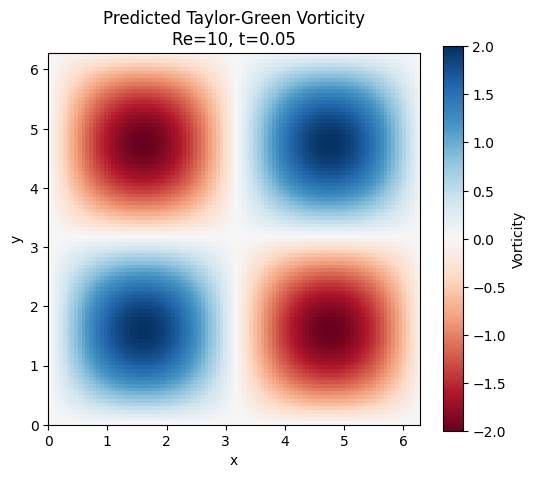

In [99]:
plt.figure(figsize=(6,5))

plt.imshow(
    wm,
    extent=[0, L, 0, B],
    origin="lower",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Vorticity")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Predicted Taylor-Green Vorticity\nRe={1/nu:.0f}, t={T}")

plt.show()

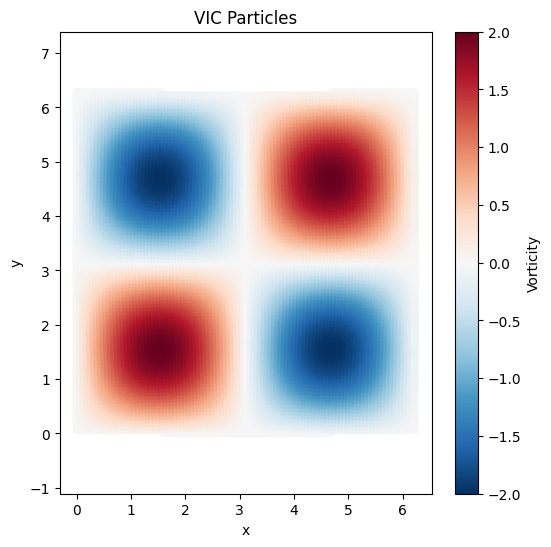

In [27]:
def plot_vic_particles(particles, h, title="VIC Particles"):

    x = np.array([p["pos"].real for p in particles])
    y = np.array([p["pos"].imag for p in particles])

    # Convert circulation back to vorticity
    w = np.array([p["a"] for p in particles]) / h**2

    #vmax = np.max(np.abs(w))

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        y,
        c=w,
        cmap="RdBu_r",
        s=25,
        vmin=-vmax,
        vmax=vmax
    )

    plt.colorbar(label="Vorticity")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.title(title)

    plt.show()

plot_vic_particles(particles, h)

In [42]:
import pickle
import os

if os.path.exists("data.pkl"):
    with open("data.pkl", "rb") as f:
        data = pickle.load(f)
else:
    data = {}

data["predicted"] = wm

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)

Fourier Mode Analysis
Vorticity matrix shape : (100, 100)
Nx                     : 100
Ny                     : 100
dx                     : 6.283185e-02
dy                     : 6.283185e-02


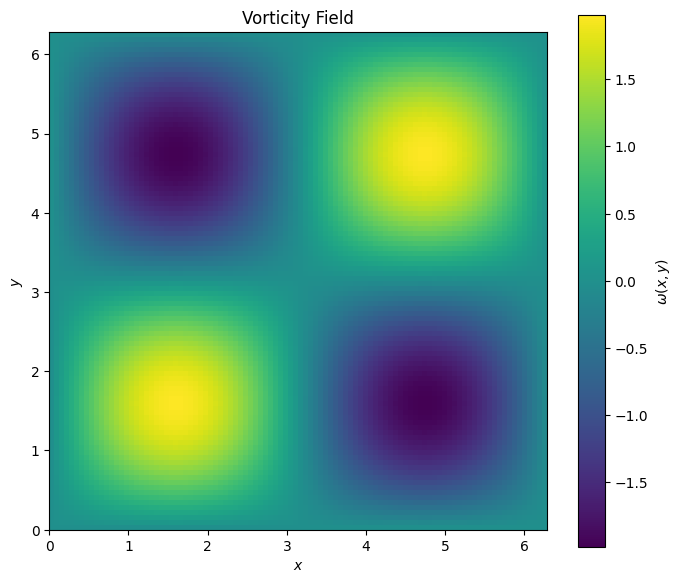

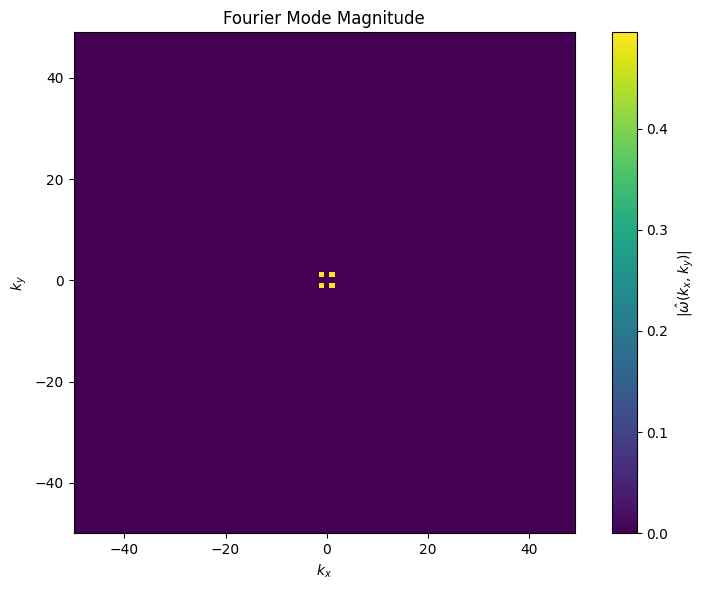

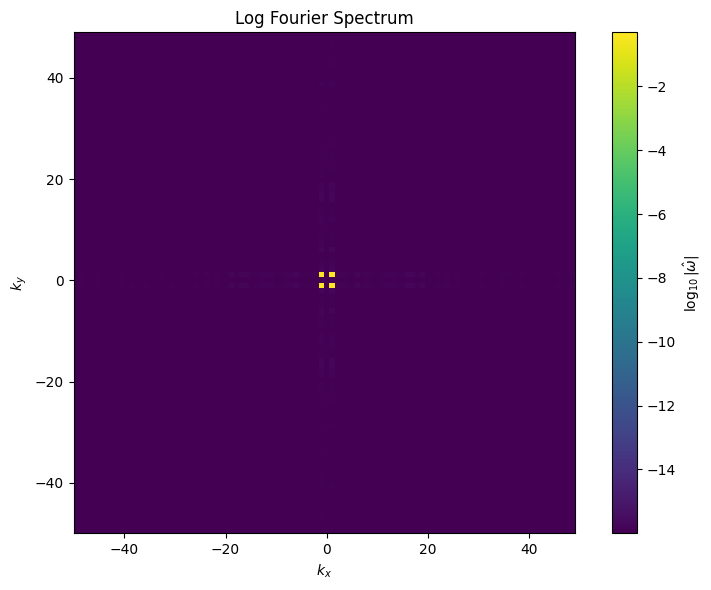

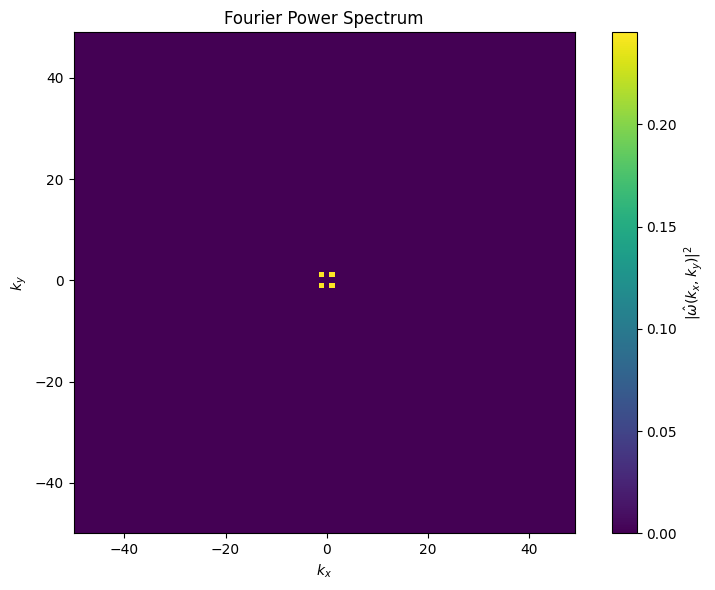

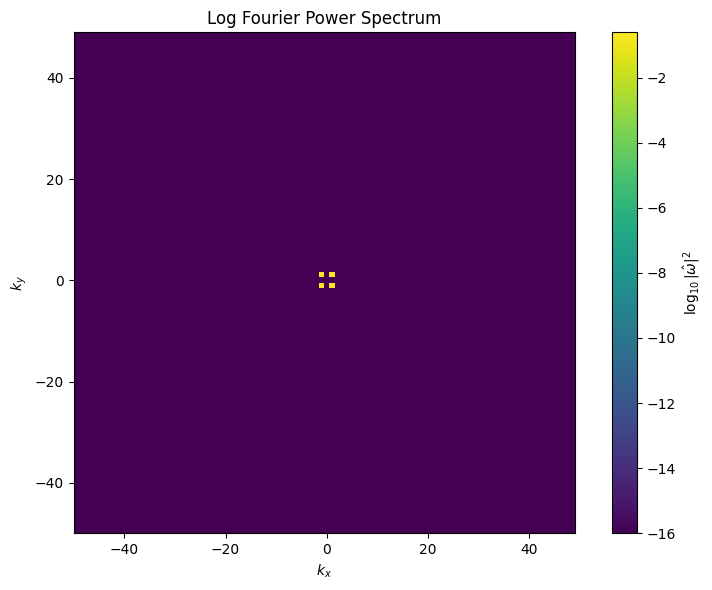

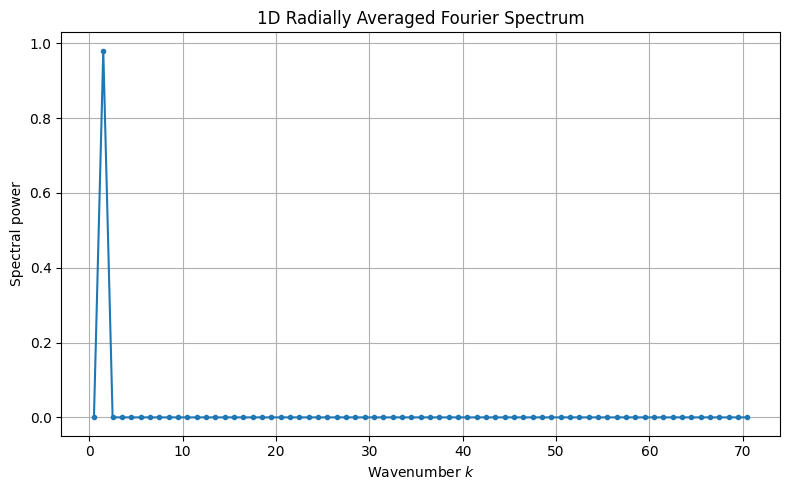

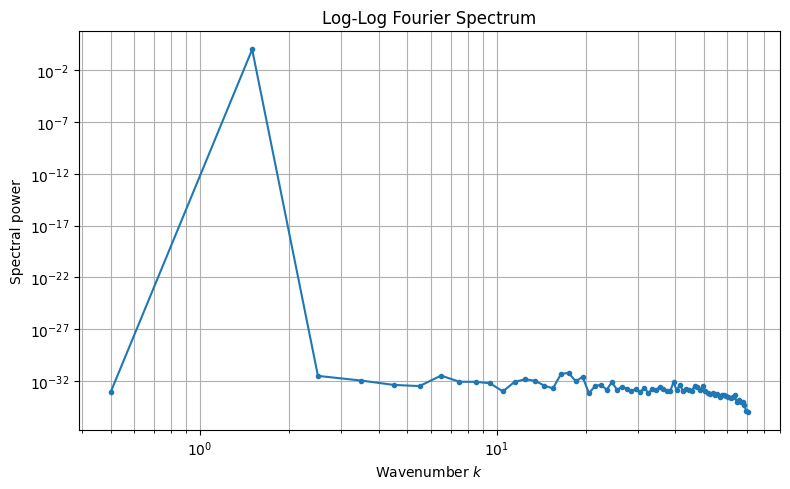



Dominant Fourier Modes
Rank    kx        ky        |omega_hat|       
------------------------------------------------------------
1       1.00      1.00      4.950249e-01      
2       -1.00     -1.00     4.950249e-01      
3       -1.00     1.00      4.950249e-01      
4       1.00      -1.00     4.950249e-01      
5       -17.00    -1.00     9.415461e-17      
6       1.00      -17.00    9.139431e-17      
7       -1.00     -17.00    9.081948e-17      
8       -1.00     17.00     8.963796e-17      
9       1.00      17.00     8.634253e-17      
10      17.00     -1.00     8.015542e-17      
11      -1.00     -16.00    7.977976e-17      
12      1.00      16.00     7.977976e-17      
13      1.00      -16.00    7.973427e-17      
14      -1.00     16.00     7.973427e-17      
15      17.00     1.00      7.907779e-17      


Strongest Fourier Mode
kx                 = 1.0000
ky                 = 1.0000
|omega_hat|        = 4.950249e-01


Spectral Statistics
Total spectral power = 9.

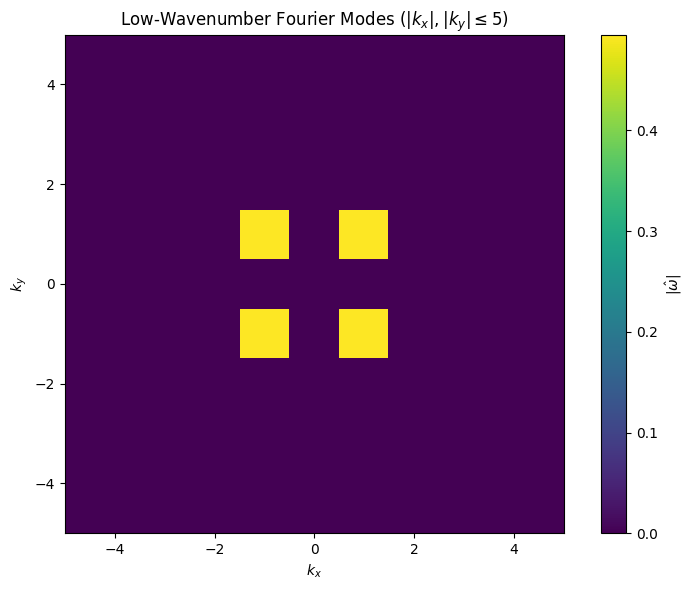



Analysis Complete


In [100]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FOURIER MODE ANALYSIS OF A 2D VORTICITY FIELD
# ============================================================

# ------------------------------------------------------------
# 1. INPUT YOUR VORTICITY MATRIX HERE
# ------------------------------------------------------------

# Example:
# omega = wm

# Replace this with your actual matrix
omega = wm


# ------------------------------------------------------------
# 2. DOMAIN PARAMETERS
# ------------------------------------------------------------

# Your Taylor-Green domain
L = 2 * np.pi       # domain length in x
B = 2 * np.pi       # domain length in y

Nx, Ny = omega.shape

dx = L / Nx
dy = B / Ny

print("============================================================")
print("Fourier Mode Analysis")
print("============================================================")
print(f"Vorticity matrix shape : {omega.shape}")
print(f"Nx                     : {Nx}")
print(f"Ny                     : {Ny}")
print(f"dx                     : {dx:.6e}")
print(f"dy                     : {dy:.6e}")


# ------------------------------------------------------------
# 3. PHYSICAL-SPACE GRID
# ------------------------------------------------------------

x = np.arange(Nx) * dx
y = np.arange(Ny) * dy

X, Y = np.meshgrid(x, y, indexing="ij")


# ------------------------------------------------------------
# 4. ORIGINAL VORTICITY FIELD
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    omega,
    extent=[0, L, 0, B],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$\omega(x,y)$")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Vorticity Field")

plt.tight_layout()
plt.show()


# ============================================================
# FOURIER TRANSFORM
# ============================================================

# ------------------------------------------------------------
# 5. 2D FFT
# ------------------------------------------------------------

omega_hat = np.fft.fft2(omega)

# Shift zero-frequency mode to the center
omega_hat_shifted = np.fft.fftshift(omega_hat)


# ------------------------------------------------------------
# 6. WAVENUMBERS
# ------------------------------------------------------------

kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)

kx_shifted = np.fft.fftshift(kx)
ky_shifted = np.fft.fftshift(ky)

KX, KY = np.meshgrid(
    kx_shifted,
    ky_shifted,
    indexing="ij"
)


# ------------------------------------------------------------
# 7. NORMALIZED FOURIER COEFFICIENTS
# ------------------------------------------------------------

# Normalization makes the coefficient magnitude independent
# of the number of grid points.

omega_hat_normalized = omega_hat / (Nx * Ny)

omega_hat_shifted_normalized = np.fft.fftshift(
    omega_hat_normalized
)


# ============================================================
# FOURIER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 8. FOURIER MODE MAGNITUDE
# ------------------------------------------------------------

fourier_magnitude = np.abs(
    omega_hat_shifted_normalized
)

plt.figure(figsize=(8, 6))

plt.imshow(
    fourier_magnitude,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$|\hat{\omega}(k_x,k_y)|$")

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Mode Magnitude")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. LOG FOURIER SPECTRUM
# ------------------------------------------------------------

# Log scale makes weak modes visible.

log_spectrum = np.log10(
    fourier_magnitude + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# POWER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 10. FOURIER POWER
# ------------------------------------------------------------

power_spectrum = fourier_magnitude ** 2

plt.figure(figsize=(8, 6))

plt.imshow(
    power_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$|\hat{\omega}(k_x,k_y)|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. LOG POWER SPECTRUM
# ------------------------------------------------------------

log_power = np.log10(
    power_spectrum + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_power,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# RADIAL / 1D FOURIER SPECTRUM
# ============================================================

# This converts the 2D spectrum into a spectrum as a function
# of total wavenumber:
#
#       k = sqrt(kx^2 + ky^2)
#
# This is often the most useful spectrum for turbulence analysis.


# ------------------------------------------------------------
# 12. WAVENUMBER MAGNITUDE
# ------------------------------------------------------------

K = np.sqrt(KX**2 + KY**2)


# ------------------------------------------------------------
# 13. CREATE WAVENUMBER BINS
# ------------------------------------------------------------

k_max = int(np.ceil(K.max()))

k_bins = np.arange(
    0,
    k_max + 1
)

k_spectrum = np.zeros(len(k_bins) - 1)


# ------------------------------------------------------------
# 14. BIN FOURIER POWER
# ------------------------------------------------------------

for i in range(len(k_bins) - 1):

    mask = (
        (K >= k_bins[i]) &
        (K < k_bins[i + 1])
    )

    k_spectrum[i] = np.sum(
        power_spectrum[mask]
    )


k_values = 0.5 * (
    k_bins[:-1] +
    k_bins[1:]
)


# ------------------------------------------------------------
# 15. PLOT 1D RADIAL SPECTRUM
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    k_spectrum,
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")
plt.title("1D Radially Averaged Fourier Spectrum")

plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. LOG-LOG RADIAL SPECTRUM
# ------------------------------------------------------------

# Ignore zero values for log-log plotting.

mask = k_spectrum > 0

plt.figure(figsize=(8, 5))

plt.loglog(
    k_values[mask],
    k_spectrum[mask],
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")

plt.title("Log-Log Fourier Spectrum")

plt.grid(True, which="both")

plt.tight_layout()
plt.show()


# ============================================================
# DOMINANT FOURIER MODES
# ============================================================

# ------------------------------------------------------------
# 17. FIND LARGEST MODES
# ------------------------------------------------------------

magnitude_original = np.abs(
    omega_hat_normalized
)

flat_indices = np.argsort(
    magnitude_original.ravel()
)[::-1]


print("\n")
print("============================================================")
print("Dominant Fourier Modes")
print("============================================================")

print(
    f"{'Rank':<8}"
    f"{'kx':<10}"
    f"{'ky':<10}"
    f"{'|omega_hat|':<18}"
)

print("------------------------------------------------------------")


number_of_modes = 15

for rank, flat_index in enumerate(
    flat_indices[:number_of_modes],
    start=1
):

    i, j = np.unravel_index(
        flat_index,
        magnitude_original.shape
    )

    print(
        f"{rank:<8}"
        f"{kx[i]:<10.2f}"
        f"{ky[j]:<10.2f}"
        f"{magnitude_original[i,j]:<18.6e}"
    )


# ============================================================
# STRONGEST MODE
# ============================================================

# ------------------------------------------------------------
# 18. SINGLE STRONGEST MODE
# ------------------------------------------------------------

max_index = np.unravel_index(
    np.argmax(magnitude_original),
    magnitude_original.shape
)

i_max, j_max = max_index

dominant_kx = kx[i_max]
dominant_ky = ky[j_max]

dominant_value = magnitude_original[
    i_max,
    j_max
]


print("\n")
print("============================================================")
print("Strongest Fourier Mode")
print("============================================================")

print(f"kx                 = {dominant_kx:.4f}")
print(f"ky                 = {dominant_ky:.4f}")

print(
    f"|omega_hat|        = "
    f"{dominant_value:.6e}"
)


# ============================================================
# TOTAL SPECTRAL POWER
# ============================================================

# ------------------------------------------------------------
# 19. TOTAL POWER
# ------------------------------------------------------------

total_power = np.sum(
    power_spectrum
)

print("\n")
print("============================================================")
print("Spectral Statistics")
print("============================================================")

print(
    f"Total spectral power = "
    f"{total_power:.6e}"
)


# ============================================================
# CHECK FOR ZERO MODE
# ============================================================

# The zero mode represents the spatial mean of vorticity.

zero_mode = omega_hat_normalized[0, 0]

mean_vorticity = np.mean(omega)

print(
    f"Mean vorticity       = "
    f"{mean_vorticity:.6e}"
)

print(
    f"Zero Fourier mode    = "
    f"{zero_mode.real:.6e}"
)


# ============================================================
# OPTIONAL: SHOW ONLY LOW WAVENUMBER MODES
# ============================================================

# This is particularly useful for Taylor-Green vortex,
# because the important modes are usually at small k.

k_limit = 5

low_k_mask = (
    (np.abs(KX) <= k_limit) &
    (np.abs(KY) <= k_limit)
)

low_k_spectrum = np.where(
    low_k_mask,
    fourier_magnitude,
    np.nan
)

plt.figure(figsize=(8, 6))

plt.imshow(
    low_k_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.xlim(-k_limit, k_limit)
plt.ylim(-k_limit, k_limit)

plt.colorbar(
    label=r"$|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")

plt.title(
    f"Low-Wavenumber Fourier Modes "
    f"($|k_x|,|k_y| \leq {k_limit}$)"
)

plt.tight_layout()
plt.show()


print("\n")
print("============================================================")
print("Analysis Complete")
print("============================================================")

Real vs. control contamination check
--- YOUR FIELD (wm) ---
  power in the 4 physical modes : 100.000000% of total
  power OUTSIDE physical modes  : 0.000e+00  (fraction of total)
  max |omega_hat| outside       : 9.415e-17
--- CONTROL (exact IC, zero solver error) ---
  power in the 4 physical modes : 100.000000% of total
  power OUTSIDE physical modes  : 0.000e+00  (fraction of total)
  max |omega_hat| outside       : 6.829e-17

Your field's off-mode energy is ~1.4x the pure-roundoff control floor.
-> Close to the floor: what you're seeing is almost certainly a
   PLOTTING/roundoff artifact, not a real numerical problem.



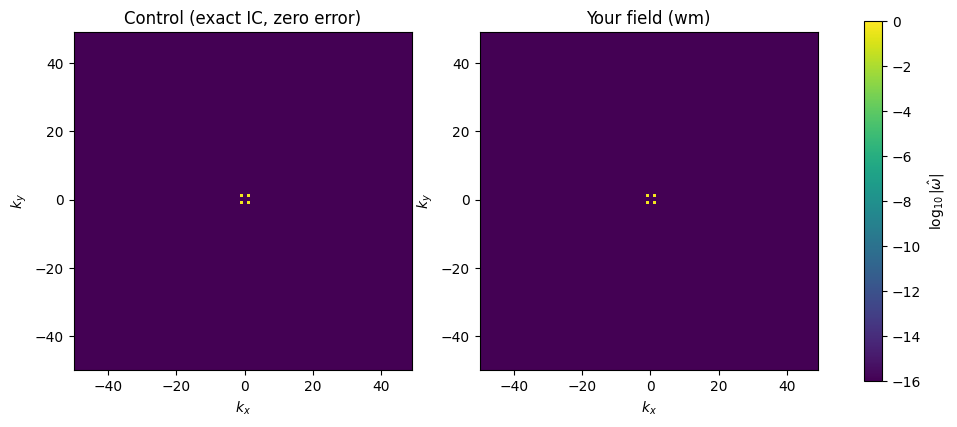

If the LEFT (control) panel still shows checkering, that confirms
it's a rendering artifact -- it CANNOT be a solver bug, since no
solver touched this field. Compare the two panels directly.


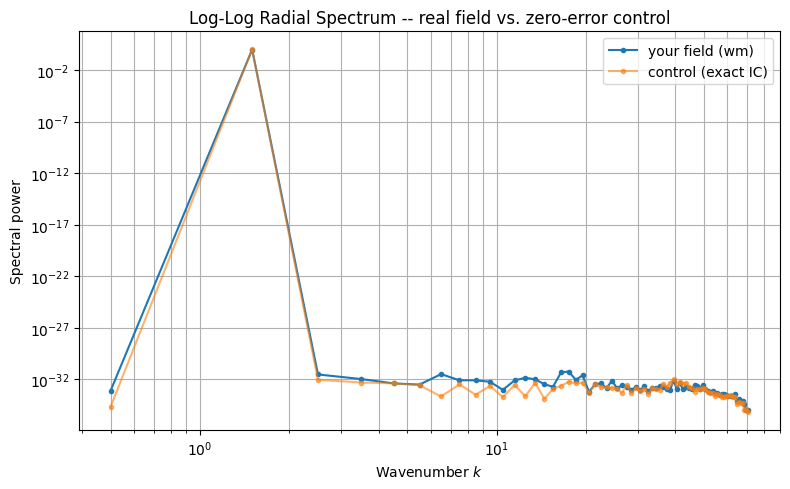

Anywhere the two curves overlap, your field is at the same level as
the zero-error control -- i.e. at the noise floor, not real content.
Only where 'your field' sits CLEARLY above the control curve is
there genuine spectral energy beyond the expected physical mode.

Dominant Fourier modes (flagged against the noise floor)
Rank  kx      ky      |omega_hat|     status      
------------------------------------------------------------
1     1.00    1.00    4.950249e-01    REAL        
2     -1.00   -1.00   4.950249e-01    REAL        
3     -1.00   1.00    4.950249e-01    REAL        
4     1.00    -1.00   4.950249e-01    REAL        
5     -17.00  -1.00   9.415461e-17    noise floor 
6     1.00    -17.00  9.139431e-17    noise floor 
7     -1.00   -17.00  9.081948e-17    noise floor 
8     -1.00   17.00   8.963796e-17    noise floor 
9     1.00    17.00   8.634253e-17    noise floor 
10    17.00   -1.00   8.015542e-17    noise floor 
11    -1.00   -16.00  7.977976e-17    noise floor 
12 

In [101]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FOURIER ANALYSIS OF A 2D VORTICITY FIELD -- WITH A BUILT-IN
# "IS THIS REAL OR IS IT PLOTTING" CONTROL COMPARISON
# ============================================================
#
# The core idea: rather than staring at a checkered plot and
# guessing, run the IDENTICAL pipeline on a case with a KNOWN,
# essentially-zero-error answer -- the pure analytic Taylor-Green
# IC sampled on your grid, never touched by your solver. Its true
# spectrum has exactly 4 nonzero modes, at (kx,ky) = (+-1,+-1);
# everything else should be at the double-precision floor
# (~1e-16 relative), not a real feature.
#
# If your actual field's "power outside the physical modes" is
# close to that floor, any checkering you see when plotting it is
# a visualization artifact (imshow resampling a small array +
# log-colour-mapping near-zero, effectively-random roundoff noise).
# If it's orders of magnitude above the floor, that's real
# spectral contamination worth chasing (e.g. the directional-
# splitting / remeshing-kernel leakage we've traced before).

# ------------------------------------------------------------
# 1. INPUT
# ------------------------------------------------------------

omega = wm          # <-- your actual vorticity matrix
L = 2 * np.pi
B = 2 * np.pi
Nx, Ny = omega.shape
dx, dy = L / Nx, B / Ny


# ------------------------------------------------------------
# 2. SPECTRUM HELPER
# ------------------------------------------------------------

def compute_spectrum(field, Nx, Ny, dx, dy):
    kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
    ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
    field_hat = np.fft.fft2(field) / (Nx * Ny)   # normalized
    return field_hat, kx, ky


def physical_mode_mask(kx, ky):
    """Where the exact Taylor-Green solution's energy actually
    lives: the four corner modes at (+-1,+-1)."""
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    return (np.abs(np.abs(KX) - 1) < 0.5) & (np.abs(np.abs(KY) - 1) < 0.5)


def report_contamination(field_hat, kx, ky, label):
    mag = np.abs(field_hat)
    mask = physical_mode_mask(kx, ky)
    power_total = np.sum(mag**2)
    power_phys = np.sum(mag[mask]**2)
    power_out = power_total - power_phys
    max_out = np.max(mag[~mask]) if np.any(~mask) else 0.0
    frac_out = power_out / power_total if power_total > 0 else 0.0
    print(f"--- {label} ---")
    print(f"  power in the 4 physical modes : {100*power_phys/power_total:.6f}% of total")
    print(f"  power OUTSIDE physical modes  : {frac_out:.3e}  (fraction of total)")
    print(f"  max |omega_hat| outside       : {max_out:.3e}")
    return frac_out, max_out


# ------------------------------------------------------------
# 3. BUILD THE ZERO-ERROR CONTROL (same grid, exact analytic IC,
#    never touched by your solver) -- this is the reference for
#    "what does a genuinely clean field's spectrum look like on
#    this exact plotting pipeline"
# ------------------------------------------------------------

x = np.arange(Nx) * dx
y = np.arange(Ny) * dy
Xc, Yc = np.meshgrid(x, y, indexing="ij")
omega_control = 2 * np.sin(Xc) * np.sin(Yc)

omega_hat, kx, ky = compute_spectrum(omega, Nx, Ny, dx, dy)
control_hat, _, _ = compute_spectrum(omega_control, Nx, Ny, dx, dy)

print("=" * 60)
print("Real vs. control contamination check")
print("=" * 60)
frac_real, max_real = report_contamination(omega_hat, kx, ky, "YOUR FIELD (wm)")
frac_ctrl, max_ctrl = report_contamination(control_hat, kx, ky, "CONTROL (exact IC, zero solver error)")
print()
ratio = max_real / max(max_ctrl, 1e-300)
print(f"Your field's off-mode energy is ~{ratio:.1f}x the pure-roundoff control floor.")
if ratio < 1e3:
    print("-> Close to the floor: what you're seeing is almost certainly a")
    print("   PLOTTING/roundoff artifact, not a real numerical problem.")
else:
    print("-> Well above the floor: this is REAL spectral contamination,")
    print("   worth investigating in the solver (not just the plot).")
print()


# ------------------------------------------------------------
# 4. SIDE-BY-SIDE SPECTRUM PLOT, ARTIFACT-FREE RENDERING
#
#    interpolation='nearest' is the key fix: matplotlib's default
#    interpolation resamples/antialiases when the array doesn't
#    map 1:1 to display pixels, and THAT resampling is what
#    produces moire/checkerboard texture -- independent of
#    whatever the underlying data actually looks like.
# ------------------------------------------------------------

kx_s = np.fft.fftshift(kx)
ky_s = np.fft.fftshift(ky)
extent = [kx_s.min(), kx_s.max(), ky_s.min(), ky_s.max()]

log_real = np.log10(np.abs(np.fft.fftshift(omega_hat)) + 1e-300)
log_ctrl = np.log10(np.abs(np.fft.fftshift(control_hat)) + 1e-300)
vmin, vmax = -16, 0   # fixed, shared scale -- so the two panels are
                       # actually comparable, not each auto-stretched

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, data, title in zip(
    axes, [log_ctrl, log_real],
    ["Control (exact IC, zero error)", "Your field (wm)"]
):
    im = ax.imshow(
        data, extent=extent, origin="lower", aspect="equal",
        interpolation="nearest", vmin=vmin, vmax=vmax
    )
    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_title(title)
fig.colorbar(im, ax=axes, label=r"$\log_{10}|\hat{\omega}|$", shrink=0.85)
plt.show()

print("If the LEFT (control) panel still shows checkering, that confirms")
print("it's a rendering artifact -- it CANNOT be a solver bug, since no")
print("solver touched this field. Compare the two panels directly.")


# ------------------------------------------------------------
# 5. RADIAL SPECTRUM WITH AN EXPLICIT NOISE-FLOOR LINE
# ------------------------------------------------------------

KX, KY = np.meshgrid(kx_s, ky_s, indexing="ij")
K = np.sqrt(KX**2 + KY**2)
power = np.abs(np.fft.fftshift(omega_hat))**2
control_power = np.abs(np.fft.fftshift(control_hat))**2

k_max = int(np.ceil(K.max()))
k_bins = np.arange(0, k_max + 1)
k_vals = 0.5 * (k_bins[:-1] + k_bins[1:])
k_spec = np.zeros(len(k_bins) - 1)
k_spec_ctrl = np.zeros(len(k_bins) - 1)
for i in range(len(k_bins) - 1):
    mask = (K >= k_bins[i]) & (K < k_bins[i + 1])
    k_spec[i] = np.sum(power[mask])
    k_spec_ctrl[i] = np.sum(control_power[mask])

plt.figure(figsize=(8, 5))
m1 = k_spec > 0
m2 = k_spec_ctrl > 0
plt.loglog(k_vals[m1], k_spec[m1], "o-", ms=3, label="your field (wm)")
plt.loglog(k_vals[m2], k_spec_ctrl[m2], "o-", ms=3, alpha=0.6, label="control (exact IC)")
plt.xlabel(r"Wavenumber $k$")
plt.ylabel("Spectral power")
plt.title("Log-Log Radial Spectrum -- real field vs. zero-error control")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

print("Anywhere the two curves overlap, your field is at the same level as")
print("the zero-error control -- i.e. at the noise floor, not real content.")
print("Only where 'your field' sits CLEARLY above the control curve is")
print("there genuine spectral energy beyond the expected physical mode.")


# ------------------------------------------------------------
# 6. DOMINANT MODES, WITH NOISE-FLOOR FLAGGING
# ------------------------------------------------------------

mag = np.abs(omega_hat)
noise_floor = max_ctrl * 10   # small safety margin above the control's own floor
flat_idx = np.argsort(mag.ravel())[::-1]

print()
print("=" * 60)
print("Dominant Fourier modes (flagged against the noise floor)")
print("=" * 60)
print(f"{'Rank':<6}{'kx':<8}{'ky':<8}{'|omega_hat|':<16}{'status':<12}")
print("-" * 60)
for rank, idx in enumerate(flat_idx[:15], start=1):
    i, j = np.unravel_index(idx, mag.shape)
    val = mag[i, j]
    status = "REAL" if val > noise_floor else "noise floor"
    print(f"{rank:<6}{kx[i]:<8.2f}{ky[j]:<8.2f}{val:<16.6e}{status:<12}")

In [ ]:
print(omega_hat)
print(control_hat)

[[-5.77637030e-17+0.00000000e+00j -2.59803174e-17-2.14242881e-16j
   5.68922676e-17-3.62573253e-17j ...  3.16730767e-17-4.19788930e-17j
   5.68920507e-17+3.62584528e-17j -2.78010832e-17+2.09446718e-16j]
 [-3.00426345e-17-1.88202837e-16j -4.95753384e-01+6.26282169e-02j
   2.04711024e-16+3.84560295e-17j ...  4.56805644e-04+5.77079730e-05j
  -1.88078460e-16+6.72993175e-18j  4.99693618e-01-2.84217094e-17j]
 [ 4.41183377e-17+3.86433169e-17j  1.55724793e-16-3.28909987e-18j
  -3.68595779e-17-1.43739621e-17j ...  5.37591606e-17+8.17398005e-17j
  -5.45539308e-17-4.04907878e-17j -1.55019463e-16-7.71034870e-17j]
 ...
 [ 3.89106478e-17-8.38838243e-17j  4.56805644e-04+5.77079730e-05j
   3.82405064e-17+2.03200176e-17j ... -5.54195907e-06-2.19421682e-06j
  -1.13844824e-16+1.34812983e-16j -4.45970868e-04-1.14505857e-04j]
 [ 4.41183377e-17-3.86433169e-17j -1.64225728e-16+7.85977301e-17j
  -5.45580752e-17+4.04911673e-17j ... -3.58133782e-17-4.72975479e-17j
  -3.68603877e-17+1.43743090e-17j  1.49902943e-